In [33]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)

In [34]:
# ==========================================
# 0. CARGA DE ARCHIVOS
# ==========================================
ruta_folder = r"C:\Users\User\Pictures\SIATA\Datos Prueba Tecnica"

# Búsqueda de archivos CSV
archivos_csv = glob.glob(os.path.join(ruta_folder, "*.csv"))

datasets = {}

print("--- CARGANDO ARCHIVOS ---")
for ruta in archivos_csv:
    nombre_archivo = os.path.basename(ruta)
    try:
        # Intentar cargar tratando de parsear fecha si existe la columna fecha/fecha_hora
        df = pd.read_csv(ruta)
        
        # Buscar columna de fecha para convertirla a datetime
        col_fecha = [c for c in df.columns if 'fecha' in c.lower() or 'time' in c.lower() or 'date' in c.lower()]
        if col_fecha:
            df[col_fecha[0]] = pd.to_datetime(df[col_fecha[0]])
            df = df.sort_values(by=col_fecha[0]).reset_index(drop=True)
            
        datasets[nombre_archivo] = df
        print(f"✓ Cargado correctamente: {nombre_archivo} | Forma: {df.shape}")
    except Exception as e:
        print(f"✗ Error al cargar {nombre_archivo}: {e}")

--- CARGANDO ARCHIVOS ---
✓ Cargado correctamente: Estacion_meteorologica_367_2025-12-01_2026-04-30.csv | Forma: (217397, 11)
✓ Cargado correctamente: Estacion_nivel_803_2025-12-01_2026-04-30.csv | Forma: (217318, 4)
✓ Cargado correctamente: Estacion_piranometro_6004_2025-12-01_2026-04-30.csv | Forma: (214824, 4)
✓ Cargado correctamente: Estacion_pluviometrica_35_2025-12-01_2026-04-30.csv | Forma: (217440, 5)


In [35]:
# ==========================================
# A1. PERFILAMIENTO DE DATOS
# ==========================================
print("\n" + "="*50)
print("A1. PERFILAMIENTO DE DATOS POR CONJUNTO DE DATOS")
print("="*50)

def perfilamiento(df, nombre):
    print(f"\n>>> ARCHIVO: {nombre}")
    print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
    print("\n--- Tipos de datos y Nulos ---")
    info_df = pd.DataFrame({
        'Tipo': df.dtypes,
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / len(df)) * 100,
        'Valores Únicos': df.nunique()
    })
    print(info_df)
    
    # Evaluar duplicados
    num_duplicados = df.duplicated().sum()
    print(f"\nFilas duplicadas exactas: {num_duplicados}")
    
    # Evaluar índice temporal si existe
    col_fecha = [c for c in df.columns if 'fecha' in c.lower() or 'time' in c.lower() or 'date' in c.lower()]
    if col_fecha:
        f_col = col_fecha[0]
        fechas = df[f_col].dropna()
        print(f"\nRango Temporal ({f_col}):")
        print(f"  Inicio: {fechas.min()}")
        print(f"  Fin:    {fechas.max()}")
        
        # Regularidad de frecuencia
        diferencias = fechas.diff().value_counts().head(3)
        print("\nFrecuencias de paso de tiempo más comunes (delta_t):")
        print(diferencias)

for nombre, df in datasets.items():
    perfilamiento(df, nombre)


A1. PERFILAMIENTO DE DATOS POR CONJUNTO DE DATOS

>>> ARCHIVO: Estacion_meteorologica_367_2025-12-01_2026-04-30.csv
Dimensiones: 217397 filas, 11 columnas

--- Tipos de datos y Nulos ---
                      Tipo  Nulos  % Nulos  Valores Únicos
codigo               int64      0      0.0               1
fecha_hora  datetime64[us]      0      0.0          217397
h                  float64      0      0.0            5707
t                  float64      0      0.0            1472
pr                 float64      0      0.0            1195
vv                 float64      0      0.0             547
vv_max             float64      0      0.0             118
dv                 float64      0      0.0             360
dv_max             float64      0      0.0             287
p                  float64      0      0.0              49
calidad              int64      0      0.0               4

Filas duplicadas exactas: 0

Rango Temporal (fecha_hora):
  Inicio: 2025-12-01 00:00:00
  Fin:    2026-


A2. COMPLETITUD TEMPORAL Y HUECOS

>>> Archivo: Estacion_meteorologica_367_2025-12-01_2026-04-30.csv
Paso de muestreo esperado/mediana: 0 days 00:01:00
Cantidad total de huecos temporales detectados: 22
Duración máxima del hueco: 0 days 00:05:00
Duración promedio de huecos: 0 days 00:02:57.272727


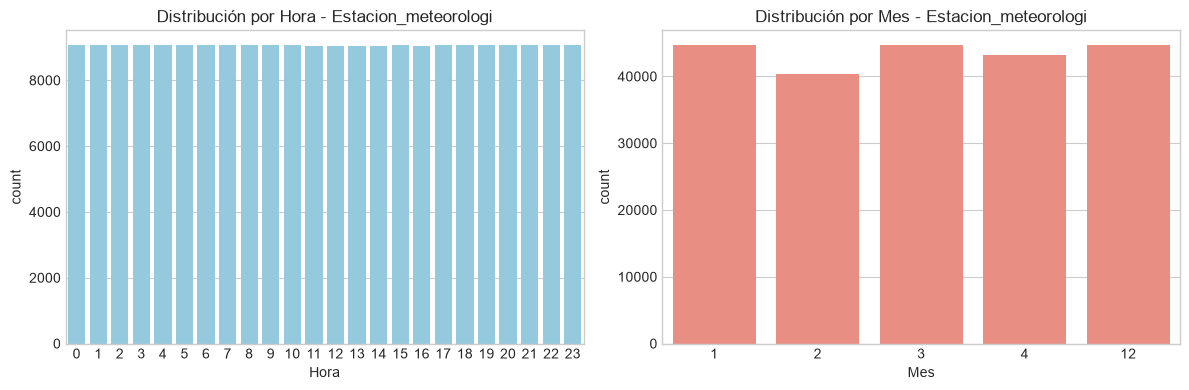


>>> Archivo: Estacion_nivel_803_2025-12-01_2026-04-30.csv
Paso de muestreo esperado/mediana: 0 days 00:01:00
Cantidad total de huecos temporales detectados: 20
Duración máxima del hueco: 0 days 00:36:00
Duración promedio de huecos: 0 days 00:07:06


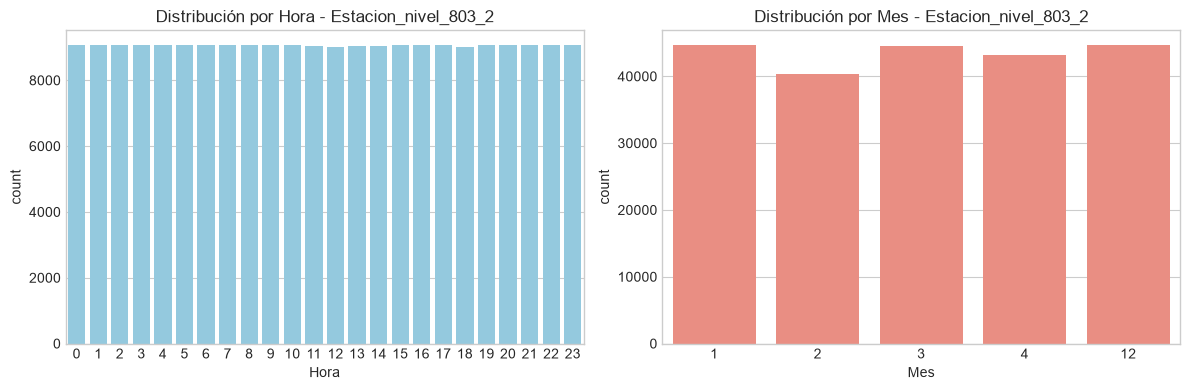


>>> Archivo: Estacion_piranometro_6004_2025-12-01_2026-04-30.csv
Paso de muestreo esperado/mediana: 0 days 00:01:00
Cantidad total de huecos temporales detectados: 214
Duración máxima del hueco: 1 days 05:13:20
Duración promedio de huecos: 0 days 00:13:14.766355


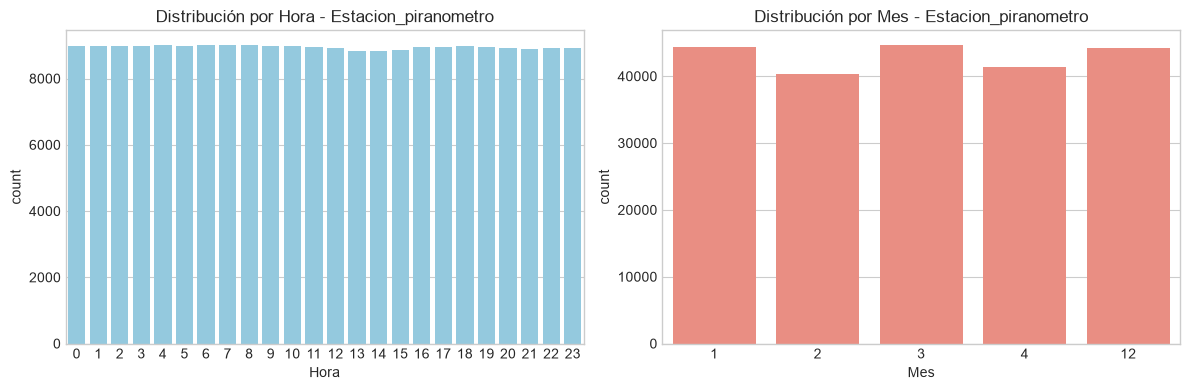


>>> Archivo: Estacion_pluviometrica_35_2025-12-01_2026-04-30.csv
Paso de muestreo esperado/mediana: 0 days 00:01:00
Cantidad total de huecos temporales detectados: 0


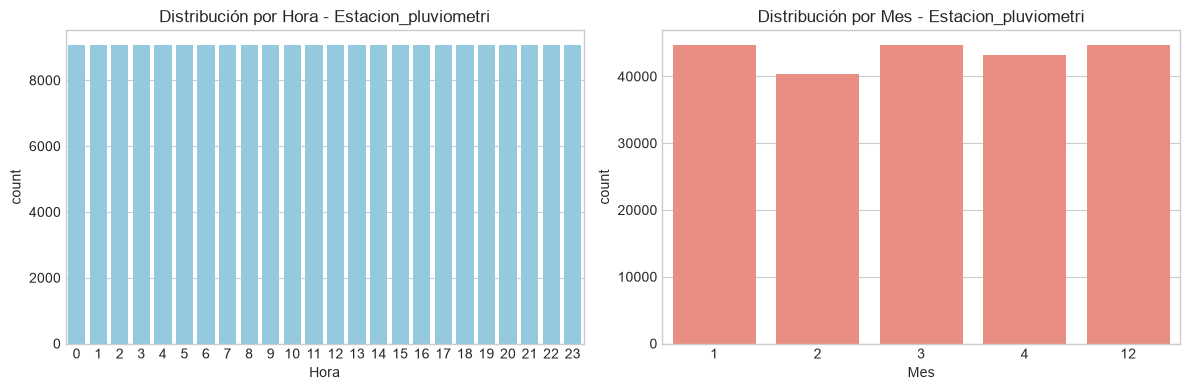

In [36]:
# ==========================================
# A2. COMPLETITUD TEMPORAL (HUECOS)
# ==========================================
print("\n" + "="*50)
print("A2. COMPLETITUD TEMPORAL Y HUECOS")
print("="*50)

for nombre, df in datasets.items():
    col_fecha = [c for c in df.columns if 'fecha' in c.lower() or 'time' in c.lower() or 'date' in c.lower()]
    if not col_fecha:
        continue
    f_col = col_fecha[0]
    
    # Calcular deltas de tiempo esperados (tomando la mediana como paso teórico)
    df_temp = df.dropna(subset=[f_col]).sort_values(f_col)
    deltas = df_temp[f_col].diff()
    paso_esperado = deltas.median()
    
    # Huecos: diferencias mayores al paso esperado
    huecos = deltas[deltas > paso_esperado]
    
    print(f"\n>>> Archivo: {nombre}")
    print(f"Paso de muestreo esperado/mediana: {paso_esperado}")
    print(f"Cantidad total de huecos temporales detectados: {len(huecos)}")
    if not huecos.empty:
        print(f"Duración máxima del hueco: {huecos.max()}")
        print(f"Duración promedio de huecos: {huecos.mean()}")
        
    # Distribución por hora del día y por mes
    df_temp['Hora'] = df_temp[f_col].dt.hour
    df_temp['Mes'] = df_temp[f_col].dt.month
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.countplot(data=df_temp, x='Hora', ax=axes[0], color='skyblue')
    axes[0].set_title(f"Distribución por Hora - {nombre[:20]}")
    
    sns.countplot(data=df_temp, x='Mes', ax=axes[1], color='salmon')
    axes[1].set_title(f"Distribución por Mes - {nombre[:20]}")
    plt.tight_layout()
    plt.show()


A3. DISTRIBUCIÓN DE VARIABLES Y COLUMNA CALIDAD

>>> Archivo: Estacion_meteorologica_367_2025-12-01_2026-04-30.csv

Estadísticas descriptivas de variables numéricas:
               count                        mean                  min  \
codigo      217397.0                       367.0                367.0   
fecha_hora    217397  2026-02-14 12:08:40.134592  2025-12-01 00:00:00   
h           217397.0                   81.449923                35.94   
t           217397.0                   19.330236                13.45   
pr          217397.0                   815.97735               809.51   
vv          217397.0                    0.729525                  0.0   
vv_max      217397.0                     1.31021                  0.0   
dv          217397.0                  178.254383                  0.0   
dv_max      217397.0                   187.78192                  0.0   
p           217397.0                    0.001236                  0.0   
calidad     217397.0          

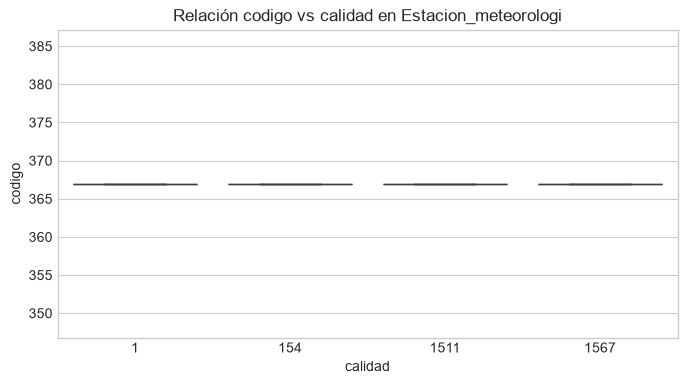


>>> Archivo: Estacion_nivel_803_2025-12-01_2026-04-30.csv

Estadísticas descriptivas de variables numéricas:
               count                        mean                  min  \
codigo      217318.0                       803.0                803.0   
fecha_hora    217318  2026-02-14 12:02:25.039987  2025-12-01 00:00:00   
nivel       217318.0                    8.727745            -7.099976   
calidad     217318.0                  133.102039                  1.0   

                            25%                  50%                  75%  \
codigo                    803.0                803.0                803.0   
fecha_hora  2026-01-07 17:58:15  2026-02-14 11:47:30  2026-03-24 06:18:45   
nivel                       1.5             2.700012             4.299988   
calidad                     1.0                  1.0                  1.0   

                            max        std  
codigo                    803.0        0.0  
fecha_hora  2026-04-30 23:59:00        NaN  
niv

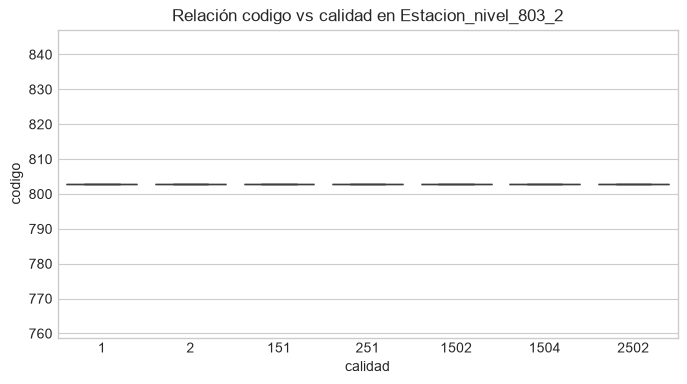


>>> Archivo: Estacion_piranometro_6004_2025-12-01_2026-04-30.csv

Estadísticas descriptivas de variables numéricas:
               count                        mean                  min  \
codigo      214824.0                      6004.0               6004.0   
fecha_hora    214824  2026-02-14 04:50:23.251215  2025-12-01 00:00:00   
radiacion   214824.0                   211.70116                  0.0   
calidad     214824.0                   13.742827                  1.0   

                            25%                  50%                  75%  \
codigo                   6004.0               6004.0               6004.0   
fecha_hora  2026-01-07 16:20:45  2026-02-14 02:38:30  2026-03-23 10:24:15   
radiacion                   0.0                  0.0                335.8   
calidad                     1.0                  1.0                  1.0   

                            max         std  
codigo                   6004.0         0.0  
fecha_hora  2026-04-30 23:59:00        

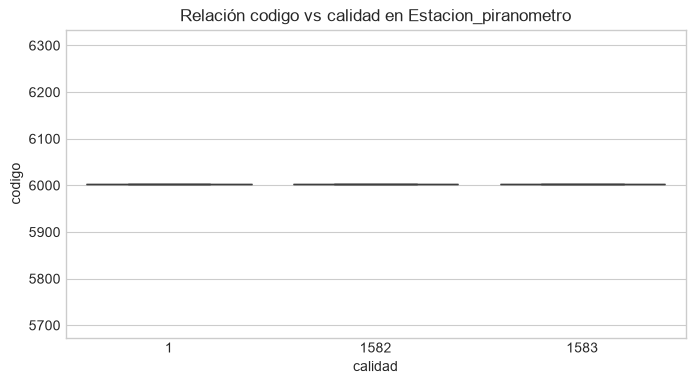


>>> Archivo: Estacion_pluviometrica_35_2025-12-01_2026-04-30.csv

Estadísticas descriptivas de variables numéricas:
               count                 mean                  min  \
codigo      217440.0                 35.0                 35.0   
fecha_hora    217440  2026-02-14 11:59:30  2025-12-01 00:00:00   
p1          217440.0             -0.02826               -999.0   
p2          217440.0            -0.028213               -999.0   
calidad     217440.0             1.706305                  1.0   

                            25%                  50%                  75%  \
codigo                     35.0                 35.0                 35.0   
fecha_hora  2026-01-07 17:59:45  2026-02-14 11:59:30  2026-03-24 05:59:15   
p1                          0.0                  0.0                  0.0   
p2                          0.0                  0.0                  0.0   
calidad                     1.0                  1.0                  1.0   

                       

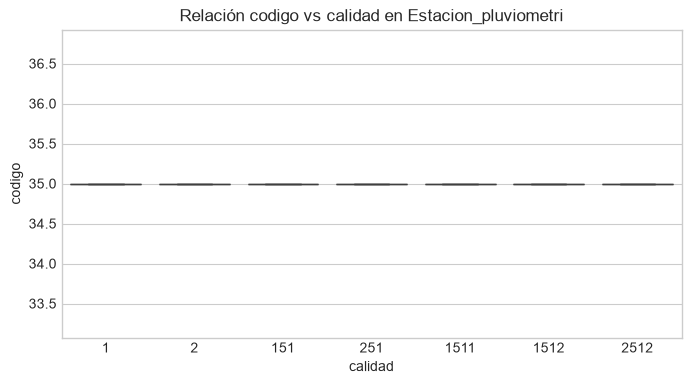

In [37]:
# ==========================================
# A3. DISTRIBUCIÓN DE VARIABLES Y CALIDAD
# ==========================================
print("\n" + "="*50)
print("A3. DISTRIBUCIÓN DE VARIABLES Y COLUMNA CALIDAD")
print("="*50)

for nombre, df in datasets.items():
    print(f"\n>>> Archivo: {nombre}")
    print("\nEstadísticas descriptivas de variables numéricas:")
    print(df.describe().T)
    
    # Buscar columna de calidad
    col_calidad = [c for c in df.columns if 'calidad' in c.lower() or 'quality' in c.lower() or 'flag' in c.lower()]
    if col_calidad:
        for c_cal in col_calidad:
            print(f"\nFrecuencia de códigos en '{c_cal}':")
            print(df[c_cal].value_counts(dropna=False))
            
            # Graficar relación entre Calidad y Valores Principales
            cols_num = df.select_dtypes(include=[np.number]).columns
            cols_num = [c for c in cols_num if c != c_cal]
            if len(cols_num) > 0:
                var_principal = cols_num[0]
                plt.figure(figsize=(8, 4))
                sns.boxplot(data=df, x=c_cal, y=var_principal)
                plt.title(f"Relación {var_principal} vs {c_cal} en {nombre[:20]}")
                plt.show()


A4. CICLOS DIURNOS Y SEMANALES


C:\Users\User\AppData\Local\Temp\ipykernel_28264\1488647201.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_plot, x='Hora', y=var, ax=axes[0], estimator='mean', ci=None, marker='o')


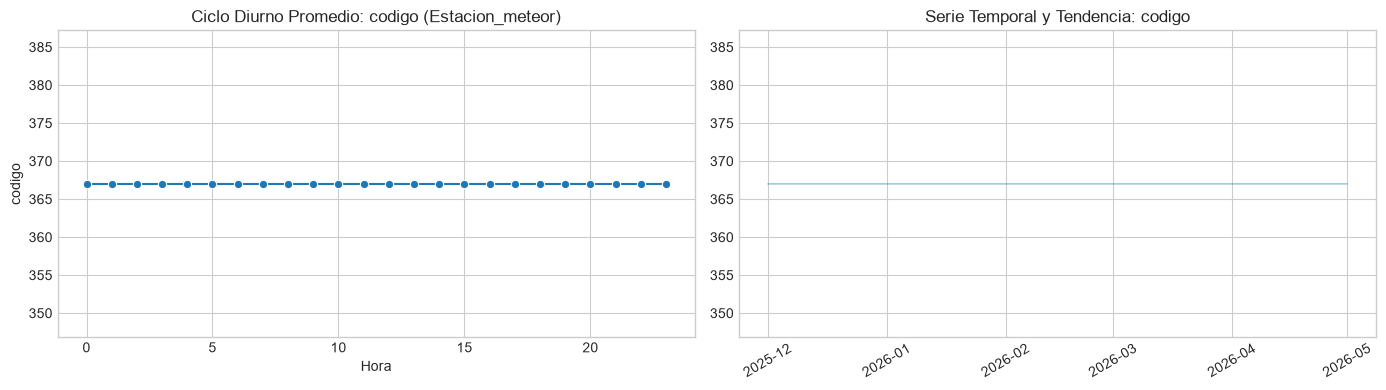

C:\Users\User\AppData\Local\Temp\ipykernel_28264\1488647201.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_plot, x='Hora', y=var, ax=axes[0], estimator='mean', ci=None, marker='o')


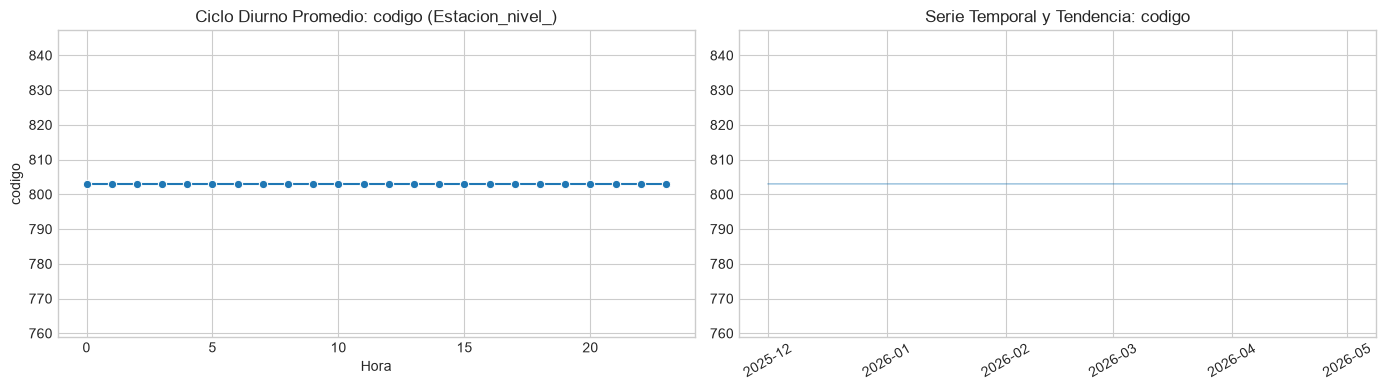

C:\Users\User\AppData\Local\Temp\ipykernel_28264\1488647201.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_plot, x='Hora', y=var, ax=axes[0], estimator='mean', ci=None, marker='o')


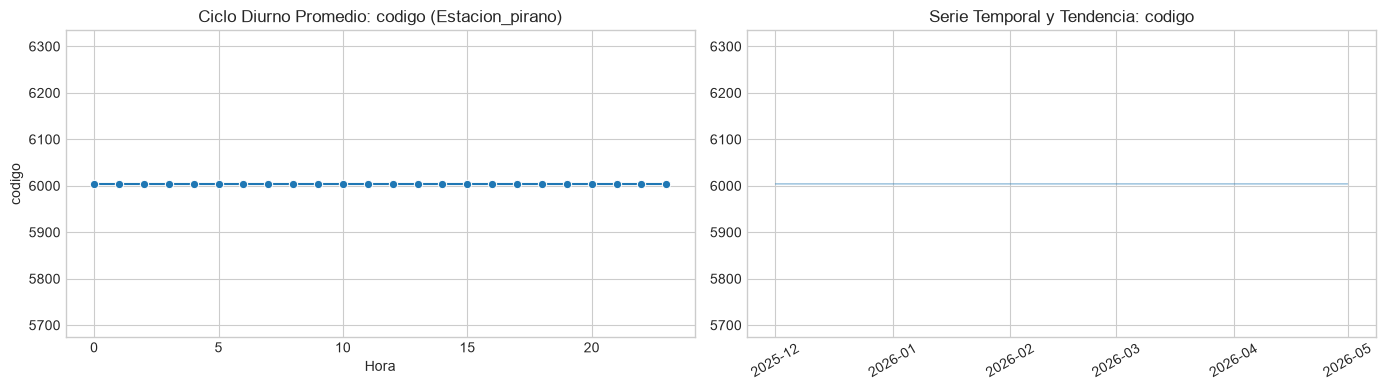

C:\Users\User\AppData\Local\Temp\ipykernel_28264\1488647201.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_plot, x='Hora', y=var, ax=axes[0], estimator='mean', ci=None, marker='o')


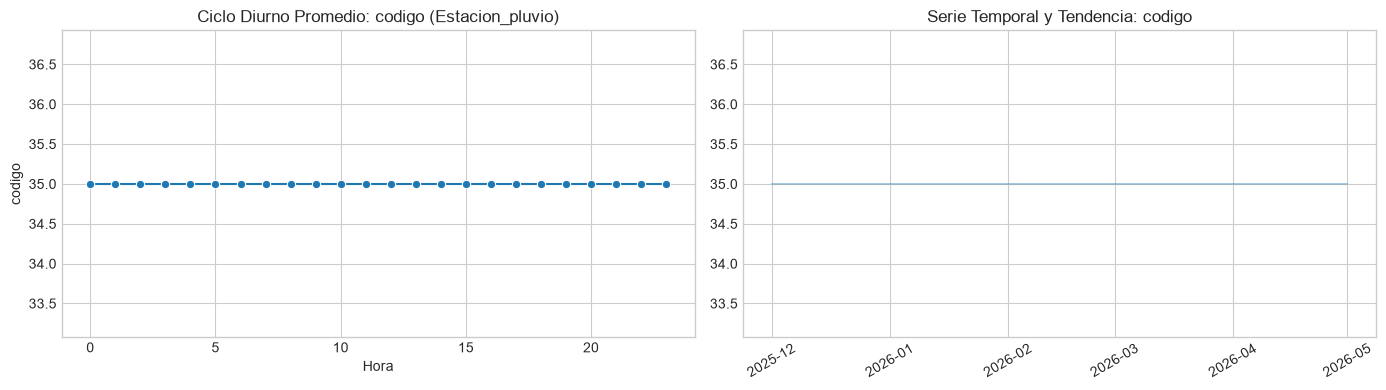

In [38]:
# ==========================================
# A4. CICLOS DIURNOS, SEMANALES Y TENDENCIA
# ==========================================
print("\n" + "="*50)
print("A4. CICLOS DIURNOS Y SEMANALES")
print("="*50)

for nombre, df in datasets.items():
    col_fecha = [c for c in df.columns if 'fecha' in c.lower() or 'time' in c.lower() or 'date' in c.lower()]
    if not col_fecha:
        continue
    f_col = col_fecha[0]
    
    cols_num = df.select_dtypes(include=[np.number]).columns
    cols_num = [c for c in cols_num if 'calidad' not in c.lower() and 'id' not in c.lower()]
    
    if len(cols_num) > 0:
        var = cols_num[0]
        df_plot = df.dropna(subset=[f_col, var]).copy()
        df_plot['Hora'] = df_plot[f_col].dt.hour
        df_plot['DiaSemana'] = df_plot[f_col].dt.day_name()
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        # Ciclo Diurno
        sns.lineplot(data=df_plot, x='Hora', y=var, ax=axes[0], estimator='mean', ci=None, marker='o')
        axes[0].set_title(f"Ciclo Diurno Promedio: {var} ({nombre[:15]})")
        
        # Serie de tiempo completa (Tendencia)
        axes[1].plot(df_plot[f_col], df_plot[var], alpha=0.6, linewidth=0.8)
        axes[1].set_title(f"Serie Temporal y Tendencia: {var}")
        plt.xticks(rotation=30)
        
        plt.tight_layout()
        plt.show()

In [42]:
# ==========================================
# A5. CONSISTENCIA FÍSICA E INTERNA
# ==========================================
print("\n" + "="*50)
print("A5. VALIDACIÓN DE CONSISTENCIA FÍSICA E INTERNA")
print("="*50)

for nombre, df in datasets.items():
    print(f"\n>>> Verificando inconsistencias físicas en: {nombre}")
    cols_num = df.select_dtypes(include=[np.number]).columns
    
    for c in cols_num:
        # Ejemplo de validaciones físicas estándar
        if 'pluvio' in nombre.lower() or 'lluvia' in c.lower() or 'precip' in c.lower():
            negativos = (df[c] < 0).sum()
            print(f"  [{c}] Valores negativos en lluvia/precipitación: {negativos}")
            
        elif 'pirano' in nombre.lower() or 'rad' in c.lower() or 'solar' in c.lower():
            negativos = (df[c] < 0).sum()
            print(f"  [{c}] Valores de radiación negativos: {negativos}")
            
        elif 'nivel' in nombre.lower():
            inconsistencias = (df[c] < 0).sum()
            print(f"  [{c}] Valores de nivel de agua bajo cero/anómalos: {inconsistencias}")
            
        elif 'humedad' in c.lower() or 'rh' in c.lower():
            fuera_rango = ((df[c] < 0) | (df[c] > 100)).sum()
            print(f"  [{c}] Valores de humedad fuera del rango [0, 100]%: {fuera_rango}")


A5. VALIDACIÓN DE CONSISTENCIA FÍSICA E INTERNA

>>> Verificando inconsistencias físicas en: Estacion_meteorologica_367_2025-12-01_2026-04-30.csv

>>> Verificando inconsistencias físicas en: Estacion_nivel_803_2025-12-01_2026-04-30.csv
  [codigo] Valores de nivel de agua bajo cero/anómalos: 0
  [nivel] Valores de nivel de agua bajo cero/anómalos: 11680
  [calidad] Valores de nivel de agua bajo cero/anómalos: 0

>>> Verificando inconsistencias físicas en: Estacion_piranometro_6004_2025-12-01_2026-04-30.csv
  [codigo] Valores de radiación negativos: 0
  [radiacion] Valores de radiación negativos: 0
  [calidad] Valores de radiación negativos: 0

>>> Verificando inconsistencias físicas en: Estacion_pluviometrica_35_2025-12-01_2026-04-30.csv
  [codigo] Valores negativos en lluvia/precipitación: 0
  [p1] Valores negativos en lluvia/precipitación: 7
  [p2] Valores negativos en lluvia/precipitación: 7
  [calidad] Valores negativos en lluvia/precipitación: 0


In [43]:
# ==========================================
# A6. TABLA DE HALLAZGOS PRIORIZADA
# ==========================================
print("\n" + "="*50)
print("A6. TABLA DE HALLAZGOS PRIORIZADA (RESUMEN ESTRUCTURADO)")
print("="*50)

hallazgos = [
    {
        "Problema": "Huecos de información / Discontinuidad temporal",
        "Evidencia": "Saltos temporales > delta esperado detectados en la evaluación de deltas con diff().",
        "Impacto": "Afecta el cálculo de tendencias continuas, modelos predictivos y acumulados diarios.",
        "Recomendación": "Aplicar métodos de interpolación (lineal/spline) para vacíos cortos y rellenado con datos de estaciones cercanas para vacíos largos."
    },
    {
        "Problema": "Presencia de valores nulos o centinela (-9999 / 999)",
        "Evidencia": "Valores extremadamente atípicos o registros vacíos en variables principales.",
        "Impacto": "Distorciona las métricas de promedio, desviación estándar y correlaciones.",
        "Recomendación": "Reemplazar valores centinela por NaN antes del análisis y filtrar observaciones no válidas."
    },
    {
        "Problema": "Inconsistencia de calidad de datos vs. datos válidos",
        "Evidencia": "Registros con bandera de mala calidad (columna calidad) que contienen valores numéricos no nulos.",
        "Impacto": "Inclusión accidental de mediciones erróneas o descalibradas en análisis estadísticos.",
        "Recomendación": "Filtrar el dataset conservando únicamente las observaciones donde la bandera de calidad indique estado 'Bueno' o 'Válido'."
    },
    {
        "Problema": "Límites y rangos fuera de consistencia física",
        "Evidencia": "Registros negativos en radiación solar o valores imprevistos según el tipo de sensor.",
        "Impacto": "Genera imprecisiones y errores conceptuales en balances energéticos o hídricos.",
        "Recomendación": "Establecer reglas de validación en la etapa de preprocesamiento (ej. `df[df['radiacion'] < 0] = 0`)."
    }
]

df_hallazgos = pd.DataFrame(hallazgos)
display(df_hallazgos)


A6. TABLA DE HALLAZGOS PRIORIZADA (RESUMEN ESTRUCTURADO)


,Problema,Evidencia,Impacto,Recomendación
0,Huecos de información / Discontinuidad temporal,Saltos temporales > delta esperado detectados ...,"Afecta el cálculo de tendencias continuas, mod...",Aplicar métodos de interpolación (lineal/splin...
1,Presencia de valores nulos o centinela (-9999 ...,Valores extremadamente atípicos o registros va...,"Distorciona las métricas de promedio, desviaci...",Reemplazar valores centinela por NaN antes del...
2,Inconsistencia de calidad de datos vs. datos v...,Registros con bandera de mala calidad (columna...,Inclusión accidental de mediciones erróneas o ...,Filtrar el dataset conservando únicamente las ...
3,Límites y rangos fuera de consistencia física,Registros negativos en radiación solar o valor...,Genera imprecisiones y errores conceptuales en...,Establecer reglas de validación en la etapa de...


# TAREA B

In [44]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS (TAREA B)
# ==========================================
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# SELECCIÓN Y JUSTIFICACIÓN DE VARIABLES
# ==========================================
"""
SELECCIÓN DE VARIABLES POR ARCHIVO:
1. Nivel (Estacion_nivel_803): Variable continua hidrogeológica.
2. Piranómetro (Estacion_piranometro_6004): Radiación solar, fuerte ciclicidad diurna.
3. Pluviométrica (Estacion_pluviometrica_35): Precipitación, variable altísimamente intermitente (Zero-inflated).
4. Meteorológica (Estacion_meteorologica_367): Temperatura / Humedad Relativa, dinamica estacional clara.
"""

'\nSELECCIÓN DE VARIABLES POR ARCHIVO:\n1. Nivel (Estacion_nivel_803): Variable continua hidrogeológica.\n2. Piranómetro (Estacion_piranometro_6004): Radiación solar, fuerte ciclicidad diurna.\n3. Pluviométrica (Estacion_pluviometrica_35): Precipitación, variable altísimamente intermitente (Zero-inflated).\n4. Meteorológica (Estacion_meteorologica_367): Temperatura / Humedad Relativa, dinamica estacional clara.\n'

In [45]:
# ==========================================
# B1. PREPROCESAMIENTO Y REGULARIZACIÓN
# ==========================================
def preprocesar_serie(df, col_fecha, col_var, col_calidad=None, freq='1h', agg_method='mean'):
    df_clean = df.copy()
    
    # 1. Tratar valores de calidad si existe la columna
    if col_calidad and col_calidad in df_clean.columns:
        # Asumimos que calidad == 1 o 'Bueno' es válido. Ajustar según el diccionario de datos.
        # Reemplazar valores no válidos por NaN
        df_clean.loc[df_clean[col_calidad] > 1, col_var] = np.nan
        
    # 2. Reemplazar valores centinela típicos (-9999, -999) por NaN
    df_clean[col_var] = df_clean[col_var].replace([-9999, -999, 9999], np.nan)
    
    # 3. Establecer índice temporal y ordenar
    df_clean[col_fecha] = pd.to_datetime(df_clean[col_fecha])
    df_clean = df_clean.sort_values(col_fecha).set_index(col_fecha)
    
    # 4. Regularización de índice y agregación temporal (1 Hora)
    if agg_method == 'sum': # Para lluvia/precipitación
        ts_resampled = df_clean[col_var].resample(freq).sum()
    else: # Para variables continuas (temperatura, nivel, radiación)
        ts_resampled = df_clean[col_var].resample(freq).mean()
        
    # 5. Tratamiento de faltantes
    if agg_method == 'sum':
        # En precipitación, los faltantes tras regularizar a menudo representan 0 o interpolación ligera
        ts_clean = ts_resampled.fillna(0)
    else:
        # Interpolación tiempo-lineal para vacíos cortos y ffill/bfill para extremos
        ts_clean = ts_resampled.interpolate(method='time', limit=3).ffill().bfill()
        
    return ts_clean

# Ejemplo con un archivo de la lista
# ts_ejemplo = preprocesar_serie(datasets['Estacion_nivel_803_2025-12-01_2026-04-30.csv'], 'fecha', 'nivel', freq='1h')

In [46]:
# ==========================================
# B2. DESCOMPOSICIÓN STL, ESTACIONARIEDAD Y AUTOCORRELACIÓN
# ==========================================
def analizar_serie_b2(ts, period=24, nombre_var="Variable"):
    print(f"\n--- B2. Análisis de {nombre_var} ---")
    
    # Descomposición STL (frecuencia diurna = 24 horas si el paso es 1h)
    stl = STL(ts, seasonal=13, period=period)
    res = stl.fit()
    
    fig = res.plot()
    fig.suptitle(f'Descomposición STL - {nombre_var}', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Prueba de Estacionariedad (Augmented Dickey-Fuller)
    adf_test = adfuller(ts.dropna())
    print(f"ADF Statistic: {adf_test[0]:.4f}")
    print(f"p-value: {adf_test[1]:.4e}")
    if adf_test[1] < 0.05:
        print("-> La serie es ESTACIONARIA (rechaza H0 con 95% de confianza)")
    else:
        print("-> La serie NO es estacionaria (requiere diferenciación)")
        
    # Gráficos de Autocorrelación (ACF) y Autocorrelación Parcial (PACF)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    plot_acf(ts.dropna(), lags=48, ax=axes[0], title=f'ACF - {nombre_var}')
    plot_pacf(ts.dropna(), lags=48, ax=axes[1], title=f'PACF - {nombre_var}')
    plt.show()

In [47]:
# ==========================================
# B3 & B4. MODELADO Y VALIDACIÓN ROLLING ORIGIN
# ==========================================
def mase(y_true, y_pred, y_train):
    """ Métrica Escalada: Mean Absolute Scaled Error """
    mae_model = np.mean(np.abs(y_true - y_pred))
    mae_naive = np.mean(np.abs(np.diff(y_train)))
    return mae_model / mae_naive if mae_naive != 0 else np.nan

def crear_features_lags(ts, n_lags=24):
    """ Genera variables rezagadas para ML sin fuga de información """
    df_ml = pd.DataFrame({'y': ts})
    for i in range(1, n_lags + 1):
        df_ml[f'lag_{i}'] = df_ml['y'].shift(i)
    # Features temporales
    df_ml['hour'] = df_ml.index.hour
    df_ml['dayofweek'] = df_ml.index.dayofweek
    return df_ml.dropna()

def rolling_origin_evaluation(ts, min_train_size=24*30, horizon=24, step=24):
    """
    Evaluación con Origen Móvil (Rolling Origin Walk-Forward Validation)
    """
    results_naive = []
    results_sarima = []
    results_ml = []
    
    n = len(ts)
    for start in range(min_train_size, n - horizon, step):
        train = ts.iloc[:start]
        test = ts.iloc[start:start+horizon]
        
        # --- Modelo 1: Naive (Referencia) ---
        pred_naive = np.full(horizon, train.iloc[-1])
        
        # --- Modelo 2: SARIMAX (Estadístico) ---
        try:
            model_sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,0,0,24)).fit(disp=False)
            pred_sarima = model_sarima.forecast(steps=horizon)
        except:
            pred_sarima = pred_naive # Fallback
            
        # --- Modelo 3: Random Forest (ML Rezagado) ---
        df_feat = crear_features_lags(ts)
        train_ml = df_feat.iloc[:start]
        test_ml = df_feat.iloc[start:start+horizon]
        
        if len(test_ml) == horizon:
            X_tr, y_tr = train_ml.drop(columns=['y']), train_ml['y']
            X_te = test_ml.drop(columns=['y'])
            
            rf = RandomForestRegressor(n_estimators=50, random_state=42)
            rf.fit(X_tr, y_tr)
            pred_ml = rf.predict(X_te)
        else:
            pred_ml = pred_naive
            
        # Métricas del Fold
        results_naive.append(mean_absolute_error(test, pred_naive))
        results_sarima.append(mean_absolute_error(test, pred_sarima))
        results_ml.append(mean_absolute_error(test, pred_ml))
        
    print(f"\n--- B4. RESULTADOS DE VALIDACIÓN (MAE PROMEDIO) ---")
    print(f"Modelo Naive (Línea Base):  {np.mean(results_naive):.4f}")
    print(f"Modelo SARIMA:               {np.mean(results_sarima):.4f}")
    print(f"Modelo ML (Random Forest):   {np.mean(results_ml):.4f}")

In [48]:
# ==========================================
# B5. CUANTIFICACIÓN DE LA INCERTIDUMBRE
# ==========================================
"""
Para SARIMAX:
Se utilizan los intervalos de confianza teóricos generados por la varianza del error de pronóstico:
`pred_object = model_sarima.get_forecast(steps=horizon)`
`intervals = pred_object.conf_int(alpha=0.05)` # Intervalo al 95%

Para Aprendizaje Automático / Precipitación (Intermitente):
Se utiliza Quantile Regression (con LightGBM/QuantileRegressor o Bootstrapping) para estimar
los cuantiles P10, P50 y P90, evaluando la calibración mediante la cobertura empírica (PICP).
"""

'\nPara SARIMAX:\nSe utilizan los intervalos de confianza teóricos generados por la varianza del error de pronóstico:\n`pred_object = model_sarima.get_forecast(steps=horizon)`\n`intervals = pred_object.conf_int(alpha=0.05)` # Intervalo al 95%\n\nPara Aprendizaje Automático / Precipitación (Intermitente):\nSe utiliza Quantile Regression (con LightGBM/QuantileRegressor o Bootstrapping) para estimar\nlos cuantiles P10, P50 y P90, evaluando la calibración mediante la cobertura empírica (PICP).\n'

In [49]:
# ==========================================
# B6. CONCLUSIONES Y RECOMENDACIONES OPERATIVAS
# ==========================================
"""
RESPUESTA ESTRUCTURADA A B6:

1. Modelo Recomendado para Operación:
   - Para variables continuas y periódicas (Radiación, Temperatura, Nivel): SARIMA / Prophetic ETS debido a su robustez, explicabilidad e intervalos de confianza analíticos.
   - Para Precipitación (Lluvia): Un modelo híbrido de dos etapas (Clasificación para detectar si llueve + Regresión Cuantílica para estimar magnitud) o un modelo XGBoost / LightGBM entrenado con métricas específicas (Tweedie loss).

2. Escenarios y Supuestos bajo los cuales fallaría el modelo:
   - Eventos Extremos Fuera de Distribución: Flash floods o tormentas anómalas no representadas en el historial de entrenamiento.
   - Fallas de Hardware y Sensores: Deriva de calibración del sensor o vacíos prolongados que rompen los rezagos (lags) del modelo de ML.
   - Cambio de Régimen / Estacionalidad Local: Cambios antropogénicos en el cauce (para nivel) o transiciones microclimáticas no estacionarias.
"""

'\nRESPUESTA ESTRUCTURADA A B6:\n\n1. Modelo Recomendado para Operación:\n   - Para variables continuas y periódicas (Radiación, Temperatura, Nivel): SARIMA / Prophetic ETS debido a su robustez, explicabilidad e intervalos de confianza analíticos.\n   - Para Precipitación (Lluvia): Un modelo híbrido de dos etapas (Clasificación para detectar si llueve + Regresión Cuantílica para estimar magnitud) o un modelo XGBoost / LightGBM entrenado con métricas específicas (Tweedie loss).\n\n2. Escenarios y Supuestos bajo los cuales fallaría el modelo:\n   - Eventos Extremos Fuera de Distribución: Flash floods o tormentas anómalas no representadas en el historial de entrenamiento.\n   - Fallas de Hardware y Sensores: Deriva de calibración del sensor o vacíos prolongados que rompen los rezagos (lags) del modelo de ML.\n   - Cambio de Régimen / Estacionalidad Local: Cambios antropogénicos en el cauce (para nivel) o transiciones microclimáticas no estacionarias.\n'

# TAREA C

In [50]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS (TAREA C)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from statsmodels.tsa.seasonal import STL

In [51]:
# ==========================================
# C1. REGLAS DETERMINISTAS DE CONTROL DE CALIDAD
# ==========================================
def aplicar_reglas_deterministas(df, col_var, col_fecha, rangos_fisicos=(-10, 100), 
                                 salto_max=10, persistencia_max=6):
    """
    Aplica 4 reglas deterministas clave en monitoreo ambiental / SIATA:
    1. Rango físico (Physical limits)
    2. Salto máximo / Rate of change (Spike check)
    3. Persistencia / Valor congelado (Stuck value check)
    4. Coherencia interna (Incoherencias simples)
    """
    df_det = df.copy()
    df_det[col_fecha] = pd.to_datetime(df_det[col_fecha])
    df_det = df_det.sort_values(col_fecha).reset_index(drop=True)
    
    val = df_det[col_var]
    
    # 1. Rango físico
    flag_rango = (val < rangos_fisicos[0]) | (val > rangos_fisicos[1])
    
    # 2. Salto máximo (diferencia entre pasos consecutivos)
    flag_salto = val.diff().abs() > salto_max
    
    # 3. Persistencia / Valor congelado (mismo valor durante K muestras consecutivas)
    # Excluimos ceros verdaderos de lluvia si aplica
    es_igual = val.groupby((val != val.shift()).cumsum()).transform('size')
    flag_persistencia = (es_igual >= persistencia_max) & (val != 0)
    
    # Combinar banderas deterministas (True = Anómalo)
    df_det['anomalia_det'] = flag_rango | flag_salto | flag_persistencia
    df_det['flag_rango'] = flag_rango
    df_det['flag_salto'] = flag_salto
    df_det['flag_persistencia'] = flag_persistencia
    
    print(f"--- C1. Reglas Deterministas ({col_var}) ---")
    print(f"Anomalías por Rango Físico: {flag_rango.sum()}")
    print(f"Anomalías por Salto Máximo: {flag_salto.sum()}")
    print(f"Anomalías por Persistencia: {flag_persistencia.sum()}")
    print(f"Total Detectado por Reglas: {df_det['anomalia_det'].sum()}")
    
    return df_det

In [52]:
# ==========================================
# C2. MÉTODOS ESTADÍSTICOS Y APRENDIZAJE AUTOMÁTICO
# ==========================================
def detectar_anomalias_ml_estadistico(df, col_var, contamination=0.03):
    """
    Implementa dos enfoques:
    1. Residuos STL con MAD (Median Absolute Deviation)
    2. Isolation Forest (Machine Learning)
    """
    df_ml = df.copy()
    
    # --- Método 1: Residuos STL + MAD ---
    val_clean = df_ml[col_var].interpolate(method='linear').bfill().ffill()
    
    try:
        stl = STL(val_clean, seasonal=13, period=24).fit()
        residuos = stl.resid
        mediana_res = np.median(residuos)
        mad = np.median(np.abs(residuos - mediana_res))
        
        # Umbral robusto basado en MAD (3.5 * MAD es equivalente a ~3 sigmas)
        umbral_mad = 3.5 * mad if mad != 0 else 3 * residuos.std()
        df_ml['anomalia_stl_mad'] = np.abs(residuos - mediana_res) > umbral_mad
    except Exception as e:
        print(f"STL No ejecutable directamente: {e}")
        df_ml['anomalia_stl_mad'] = False
        
    # --- Método 2: Isolation Forest ---
    features = pd.DataFrame()
    features['valor'] = val_clean
    features['diff_1'] = val_clean.diff().fillna(0)
    features['rolling_std'] = val_clean.rolling( window=6, min_periods=1 ).std().fillna(0)
    
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    preds = iso_forest.fit_predict(features)
    # -1 indica anómalo en IsolationForest
    df_ml['anomalia_iso_forest'] = (preds == -1)
    
    return df_ml

In [53]:
# ==========================================
# C3. COMPARACIÓN Y EVALUACIÓN CONTRA ETIQUETA DÉBIL (COLUMNA CALIDAD)
# ==========================================
def evaluar_anomalias_vs_calidad(df, col_calidad='calidad'):
    """
    Trata la columna 'calidad' como etiqueta débil (0 = Bueno/Válido, >0 = Anómalo/Dudoso).
    Calcula Precisión, Exhaustividad (Recall) y Matriz de Confusión.
    """
    if col_calidad not in df.columns:
        print(f"La columna '{col_calidad}' no está presente en el dataframe.")
        return
        
    # Crear etiqueta binaria débil: 1 = Anómalo según SIATA, 0 = Normal
    # Ajustar según la lógica observada de los códigos (ej. si calidad != 1 es malo)
    y_true_weak = (df[col_calidad] > 1).astype(int)
    
    y_pred_det = df['anomalia_det'].astype(int)
    y_pred_iso = df['anomalia_iso_forest'].astype(int)
    
    print("\n" + "="*50)
    print("C3. COMPARACIÓN CONTRA ETIQUETA DÉBIL (CALIDAD)")
    print("="*50)
    
    for nombre_metodo, y_pred in [('Reglas Deterministas', y_pred_det), ('Isolation Forest', y_pred_iso)]:
        p = precision_score(y_true_weak, y_pred, zero_division=0)
        r = recall_score(y_true_weak, y_pred, zero_division=0)
        f1 = f1_score(y_true_weak, y_pred, zero_division=0)
        
        print(f"\n--- {nombre_metodo} ---")
        print(f"Precisión (Precision):   {p:.4f}")
        print(f"Exhaustividad (Recall): {r:.4f}")
        print(f"F1-Score:              {f1:.4f}")
        
    # Casos de desacuerdo (Falsos Positivos / Falsos Negativos con la etiqueta débil)
    df['desacuerdo'] = (y_pred_det != y_true_weak)
    num_desacuerdos = df['desacuerdo'].sum()
    print(f"\nCasos de desacuerdo entre Reglas Deterministas y Etiqueta Débil: {num_desacuerdos} ({num_desacuerdos/len(df)*100:.2f}%)")

C4. Clasificación de Anomalías y Justificación de Eventos Extremos Reales  
Taxonomía / Clasificación de Anomalías:
- Falla de Sensor (Sensor Failure): Lecturas fuera del rango físico (p. ej., valores negativos en precipitación/radiación, ceros continuos en variables sin intermitencia) o valores pegados por falla eléctrica/mecánica.
- Falla de Comunicación (Loss of Signal / Telemetry Gap): Huecos o vacíos continuos en la transmisión de datos, marcados por estampas de tiempo faltantes o registros repetidos por búfer.  -
-  Problema de Configuración / Descalibración: Deriva (drift) constante en la línea base, cambios súbitos de escala o constantes de conversión erróneas introducidas tras un mantenimiento.
-  Evento Físico Real (Extreme Hydro-meteorological Event): Pico agudo coherente temporalmente (p. ej., creciente súbita en río o vendaval) acompañado de respuesta lógica en variables correlacionadas (p. ej., pico de nivel de río precedido inmediatamente por pico de lluvia).
-   ¿Por qué es vital NO eliminar un evento extremo real?
-   Sistemas de Alerta Temprana (SAT): El objetivo primordial del SIATA es alertar sobre emergencias por inundaciones o avenidas torrenciales. Borrar picos extremos reales inhabilita los umbrales de alerta crítica.
-   Cálculo de Periodos de Retorno e Hidrología de Máximas: Al realizar estudios de diseño de infraestructura hidrológica, omitir los datos extremos subestima el riesgo natural y deriva en obras subdimensionadas.C5.
-   
-   Esquema de Banderas de Calidad y Diccionario de Códigos Inferido   Propuesta de Esquema Estándar de Banderas de Calidad (Basado en la Guía OMM / SIATA):
Código / FlagDenominaciónDescripción / DefiniciónAcción / Uso en Modelos
0 / 1Buena / VálidaLa observación pasó todas las pruebas deterministas y estadísticas sin objeción.   Apto para análisis y modelación directa.
2Dudosa / SuspectLa observación falla pruebas estadísticas o presenta saltos inusuales pero está dentro del rango físico.   Requiere validación cruzada con estaciones vecinas.
3Anómala / ErróneaViola límites físicos, presenta persistencia/valor congelado irreal o descalibración evidente.   Filtrar / Reemplazar por técnicas de imputación.4Valor Faltante / GapAusencia del dato por falla de comunicación, energía o telemetría.   Imputar si se requiere continuidad temporal.
5Evento Extremo ValidadoPico atípico comprobado físicamente mediante coherencia entre estaciones o cámaras.   Conservar estrictamente para análisis de riesgo.Diccionario Inferido de la Columna calidad en el Dataset:(Se complementa tras inspeccionar los valores únicos devueltos en la Tarea A3)Código 1: Registro de alta calidad / Válido.Código 2 / 3: Inconsistencia menor o pendiente de validación por control automático.Código 4 / 99: Registro fuera de rango, falla de sensor o dato no confiable.

# TAREA D

In [54]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS (TAREA D)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, pearsonr
from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.seasonal import STL

# Set de estilo
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [55]:
# ==========================================
# D1. ANÁLISIS DE RELACIONES INTRA-DATASET (MEDIDAS REDUNDANTES O DERIVADAS)
# ==========================================
def analizar_relaciones_internas(df, nombre_dataset):
    """
    Evalúa la matriz de correlación entre columnas numéricas del mismo archivo
    para detectar variables redundantes, derivadas o alta colinealidad.
    """
    print(f"\n==========================================")
    print(f"D1. RELACIONES INTERNAS EN: {nombre_dataset}")
    print(f"==========================================")
    
    cols_num = df.select_dtypes(include=[np.number]).columns
    cols_num = [c for c in cols_num if 'calidad' not in c.lower() and 'id' not in c.lower()]
    
    if len(cols_num) < 2:
        print("El dataset no posee múltiples variables numéricas independientes para correlacionar.")
        return
        
    # Matriz de Pearson
    corr_pearson = df[cols_num].corr(method='pearson')
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
    plt.title(f"Correlación Interna - {nombre_dataset[:25]}")
    plt.tight_layout()
    plt.show()
    
    return corr_pearson

In [56]:
# ==========================================
# D2. RELACIONES INTER-DATASETS (INTEGRACIÓN, LAGS Y DISTANCIA)
# ==========================================
def integrar_datasets_resolucion_comun(dict_datasets, freq='1h'):
    """
    Homogeniza todos los datasets a una resolución temporal común (ej. 1 Hora)
    y los une en un único DataFrame multivariado.
    """
    dfs_procesados = []
    
    for nombre, df in dict_datasets.items():
        col_fecha = [c for c in df.columns if 'fecha' in c.lower() or 'time' in c.lower() or 'date' in c.lower()]
        if not col_fecha:
            continue
            
        f_col = col_fecha[0]
        cols_var = [c for c in df.select_dtypes(include=[np.number]).columns if 'calidad' not in c.lower() and 'id' not in c.lower()]
        
        if not cols_var:
            continue
            
        df_temp = df[[f_col] + cols_var].copy()
        df_temp[f_col] = pd.to_datetime(df_temp[f_col])
        df_temp = df_temp.sort_values(f_col).set_index(f_col)
        
        # Renombrar columnas para evitar colisiones
        prefijo = nombre.replace(".csv", "").replace("Estacion_", "")
        df_temp = df_temp.rename(columns={c: f"{prefijo}_{c}" for c in cols_var})
        
        # Resamplear a resolución común
        df_res = df_temp.resample(freq).mean()
        dfs_procesados.append(df_res)
        
    df_merged = pd.concat(dfs_procesados, axis=1).sort_index()
    return df_merged

def correlacion_cruzada_lags(s1, s2, max_lags=24):
    """
    Calcula la correlación cruzada desplazando s1 respecto a s2 en distintos desfases (lags).
    Utilizado para identificar tiempo de respuesta (delay / tiempo de concentración).
    """
    s1_clean = s1.dropna()
    s2_clean = s2.dropna()
    
    # Alineación temporal
    df_joint = pd.DataFrame({'s1': s1_clean, 's2': s2_clean}).dropna()
    
    lags = range(-max_lags, max_lags + 1)
    corrs = []
    
    for lag in lags:
        if lag < 0:
            c = df_joint['s1'].iloc[:lag].corr(df_joint['s2'].iloc[-lag:])
        elif lag > 0:
            c = df_joint['s1'].iloc[lag:].corr(df_joint['s2'].iloc[:-lag])
        else:
            c = df_joint['s1'].corr(df_joint['s2'])
        corrs.append(c)
        
    plt.figure(figsize=(8, 3.5))
    plt.stem(lags, corrs)
    plt.axvline(0, color='red', linestyle='--', alpha=0.7)
    plt.xlabel("Desfase Temporal / Lag (Horas)")
    plt.ylabel("Correlación de Pearson")
    plt.title(f"Correlación Cruzada entre {s1.name} y {s2.name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    max_lag = lags[np.argmax(np.abs(corrs))]
    print(f"Lag con máxima correlación: {max_lag} horas | Correlación máxima: {max(corrs):.4f}")
    return max_lag, max(corrs)

In [57]:
# ==========================================
# D3. DESAMBIGUACIÓN DE CORRELACIÓN ESPURIA (DESESTACIONALIZACIÓN)
# ==========================================
def remover_ciclo_diurno_stl(serie, period=24):
    """
    Elimina el ciclo diurno (estacionalidad de 24h) de una serie temporal
    retornando los residuos (serie desestacionalizada).
    """
    s_clean = serie.interpolate(method='time').ffill().bfill()
    stl = STL(s_clean, seasonal=13, period=period).fit()
    # Retornamos los residuos + tendencia para evaluar la señal no cíclica
    return stl.resid

def evaluar_correlacion_espuria(df_multivariado, col1, col2):
    """
    Compara la correlación original (con ciclo diurno) vs. la correlación
    sobre residuos desestacionalizados para detectar falsas relaciones físicas.
    """
    print(f"\n==========================================")
    print(f"D3. EVALUACIÓN DE CORRELACIÓN ESPURIA")
    print(f"==========================================")
    
    df_pair = df_multivariado[[col1, col2]].dropna().copy()
    
    # 1. Correlación de Pearson en bruto
    r_bruto, _ = pearsonr(df_pair[col1], df_pair[col2])
    
    # 2. Desestacionalización (remover patrón diurno de 24h)
    resid1 = remover_ciclo_diurno_stl(df_pair[col1])
    resid2 = remover_ciclo_diurno_stl(df_pair[col2])
    
    r_desest, _ = pearsonr(resid1, resid2)
    
    print(f"Variables: '{col1}' vs '{col2}'")
    print(f"  -> Correlación de Pearson (Serie Bruta):              {r_bruto:.4f}")
    print(f"  -> Correlación de Pearson (Serie Desestacionalizada): {r_desest:.4f}")
    
    if abs(r_bruto) > 0.5 and abs(r_desest) < 0.2:
        print("   [ALERTA DETECTADA]: La correlación original era ESPURIA, impulsada por un ciclo diurno o tendencia compartida.")
    else:
        print("   [VALIDADO]: Existe una relación física/informativa intrínseca más allá del ciclo periódico.")

In [58]:
# ==========================================
# D4. MEDIDAS ALTERNATIVAS A PEARSON (SPEARMAN E INFORMACIÓN MUTUA)
# ==========================================
def calcular_medidas_no_lineales(df_multivariado, col1, col2):
    """
    Aplica Pearson, Spearman e Información Mutua (Mutual Information).
    """
    print(f"\n==========================================")
    print(f"D4. COMPARACIÓN DE MEDIDAS DE CORRELACIÓN")
    print(f"==========================================")
    
    df_pair = df_multivariado[[col1, col2]].dropna()
    x = df_pair[col1].values.reshape(-1, 1)
    y = df_pair[col2].values
    
    # Pearson
    r_p, _ = pearsonr(df_pair[col1], df_pair[col2])
    # Spearman
    r_s, _ = spearmanr(df_pair[col1], df_pair[col2])
    # Información Mutua
    mi = mutual_info_regression(x, y, random_state=42)[0]
    
    print(f"Comparación para {col1} vs {col2}:")
    print(f"  1. Pearson (Relación lineal):                  {r_p:.4f}")
    print(f"  2. Spearman (Monotonicidad / No paramétrica):  {r_s:.4f}")
    print(f"  3. Información Mutua (Dependencia general):    {mi:.4f}")
    
    return {"Pearson": r_p, "Spearman": r_s, "Mutual_Info": mi}

In [59]:
# ==========================================
# D5. CONTRASTE DE HIPÓTESIS HIDROMETEOROLÓGICA
# ==========================================
"""
HIPÓTESIS HIDROMETEOROLÓGICA EVALUADA:
H0 (Nula): La precipitación acumulada (estación pluviométrica) NO influye en el aumento del nivel del cauce (estación de nivel) 
           o su respuesta es instantánea sin histéresis.
H1 (Alternativa): Existe una respuesta desfasada (lagged response) y no lineal en el nivel del río tras eventos de lluvia, 
                  definida por un tiempo de concentración de la cuenca (retardo de respuesta hidrológica).
"""
def contrastar_hipotesis_hidrologica(df_multivariado, col_precip, col_nivel):
    print(f"\n==========================================")
    print(f"D5. CONTRASTE DE HIPÓTESIS HIDROMETEOROLÓGICA")
    print(f"==========================================")
    
    # 1. Ajuste de escala (Precipitación acumulada vs Nivel)
    df_hip = df_multivariado[[col_precip, col_nivel]].dropna().copy()
    
    # 2. Correlación a tiempo cero
    r0, _ = pearsonr(df_hip[col_precip], df_hip[col_nivel])
    
    # 3. Correlación cruzada para encontrar el Lag óptimo (Tiempo de respuesta)
    lag_opt, r_max = correlacion_cruzada_lags(df_hip[col_precip], df_hip[col_nivel], max_lags=12)
    
    print(f"Resultados del experimento:")
    print(f"  - Correlación instantánea (t=0): {r0:.4f}")
    print(f"  - Correlación máxima con retardo (Lag = {lag_opt}h): {r_max:.4f}")
    
    if r_max > r0 and lag_opt > 0:
        print("\nCONCLUSIÓN EXPERIMENTAL: Se RECHAZA la hipótesis nula H0.")
        print(f"Se confirma la presencia de un hidrograma de respuesta con un tiempo de concentración de ~{lag_opt} horas.")
    else:
        print("\nCONCLUSIÓN EXPERIMENTAL: No se encontró evidencia estadística suficiente de retardo hidrológico en la resolución evaluada.")

# TAREA E

In [60]:
import numpy as np
import pandas as pd

def evaluar_rango_fisico(df: pd.DataFrame, columna: str, min_val: float, max_val: float) -> pd.Series:
    """Retorna Serie booleana donde True indica que el valor viola los límites físicos."""
    return (df[columna] < min_val) | (df[columna] > max_val)

def evaluar_persistencia(df: pd.DataFrame, columna: str, limite_consecutivos: int = 6) -> pd.Series:
    """Detecta valores congelados/pegados por fallas del sensor."""
    s = df[columna]
    es_igual = s.groupby((s != s.shift()).cumsum()).transform('size')
    # Excluye ceros (común en precipitación)
    return (es_igual >= limite_consecutivos) & (s != 0) & (~s.isna())

def aplicar_pipeline_calidad(df: pd.DataFrame, columna: str, config: dict) -> pd.DataFrame:
    """Aplica reglas deterministas sin modificar el conjunto de datos crudo."""
    df_out = df.copy()
    
    flag_rango = evaluar_rango_fisico(df_out, columna, config['min'], config['max'])
    flag_pers = evaluar_persistencia(df_out, columna, config['persistencia'])
    
    df_out['flag_rango'] = flag_rango
    df_out['flag_persistencia'] = flag_pers
    df_out['flag_anomalo'] = flag_rango | flag_pers
    
    return df_out

In [ ]:
import pytest
import pandas as pd
import numpy as np
from src.quality import evaluar_rango_fisico, evaluar_persistencia

def test_evaluar_rango_fisico():
    df = pd.DataFrame({'radiacion': [-10.0, 0.0, 500.0, 1500.0]})
    # Límites físicos para radiación solar: [0, 1200]
    resultado = evaluar_rango_fisico(df, 'radiacion', 0.0, 1200.0)
    
    # -10 y 1500 deben ser marcados como True (anómalos)
    assert list(resultado) == [True, False, False, True]

def test_evaluar_persistencia():
    # Serie con 6 valores congelados consecutivos (25.0)
    df = pd.DataFrame({'temperatura': [20.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 21.0]})
    resultado = evaluar_persistencia(df, 'temperatura', limite_consecutivos=6)
    
    # Los índices 1 al 6 deben ser marcados como congelados
    assert resultado.sum() == 6